In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class JokeState(TypedDict):
  topic:str
  joke:str
  explanation:str

In [5]:
def generate_joke(state: JokeState):
    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content
    return {'joke': response}

def generate_explanation(state: JokeState):
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content
    return {'explanation': response}

In [6]:
graph = StateGraph(JokeState)
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

In [8]:
checkpointer = MemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

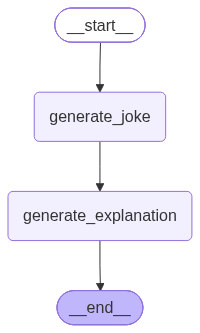

In [14]:
workflow

In [9]:
config1 = {"configurable": {"thread_id": "1"}}
result1 = workflow.invoke({'topic': 'Football'}, config=config1)
print("Thread 1 result:\n", result1, "\n")

print("Thread 1 full history:")
for snap in workflow.get_state_history(config1):
    print(" -", snap.config['configurable']['checkpoint_id'], "| next:", snap.next)
print()

Thread 1 result:
 {'topic': 'Football', 'joke': 'Why did the football go to the doctor?\n\nBecause it was feeling a little "deflated"! (get it?)', 'explanation': 'A classic play on words. This joke is funny because it\'s a clever pun. Here\'s how it works:\n\nThe setup for the joke is "Why did the football go to the doctor?" which implies that the football is sick or injured in some way. The punchline "it was feeling a little \'deflated\'" is a clever twist on the expected answer.\n\nIn football, a deflated ball is one that has lost air pressure, which can affect its performance and make it unusable for play. However, in everyday language, "deflated" can also mean feeling sad, depressed, or lacking energy.\n\nThe joke relies on this double meaning of "deflated". The football is literally a ball that can become deflated (lose air), but the word "deflated" is also used to describe a emotional state. So, when the joke says the football is "feeling a little deflated", it\'s making a wordpl

In [10]:
config2 = {"configurable": {"thread_id": "2"}}
result2 = workflow.invoke({'topic': 'Cricket'}, config=config2)
print("Thread 2 result:\n", result2, "\n")

print("Thread 2 latest state:")
print(workflow.get_state(config2), "\n")

history2 = list(workflow.get_state_history(config2))
print("Thread 2 full history (newest first):")
for snap in history2:
    print(" -", snap.config['configurable']['checkpoint_id'], "| next:", snap.next)
print()

Thread 2 result:
 {'topic': 'Cricket', 'joke': 'Why did the cricket go to the doctor?\n\nBecause it had a "sticky" wicket situation and was feeling a little "bowled" over! (get it?)', 'explanation': 'A classic joke that combines wordplay with a dash of sports terminology. Let\'s break it down:\n\nThe joke starts with a setup that\'s familiar to many: "Why did [animal/object] go to the doctor?" In this case, it\'s a cricket (the insect, not the sport).\n\nThe punchline relies on a double meaning of words related to the sport of cricket. A "sticky wicket" is a term used in cricket to describe a difficult or challenging situation on the field, often due to the condition of the pitch. However, in this joke, "sticky" also references the fact that crickets (the insects) have sticky feet, which they use to climb and perch on surfaces.\n\nThe second part of the punchline, "feeling a little \'bowled\' over," is another play on words. In cricket, a bowler is a player who throws the ball, and to 

In [ ]:
# 3. TIME TRAVEL — pick an EARLY checkpoint from thread 2's history
#    (history2[-1] is the OLDEST checkpoint, right after START)

early_checkpoint_config = history2[-1].config
print("Time-travel target checkpoint:", early_checkpoint_config, "\n")

# a) View state at that point in history (read-only)
past_state = workflow.get_state(early_checkpoint_config)
print("State at that past checkpoint:\n", past_state.values, "\n")

# b) Fork it — edit the topic at that point in history
new_branch_config = workflow.update_state(
    early_checkpoint_config,
    {'topic': 'Tennis'}
)
print("New forked checkpoint created:", new_branch_config, "\n")

# c) Resume execution FORWARD from the new forked checkpoint
resumed_result = workflow.invoke(None, new_branch_config)
print("Result after resuming from the forked ('Tennis') checkpoint:\n", resumed_result, "\n")

# d) Confirm the fork now exists in history
print("Thread 2 history AFTER the fork (should show a new branch):")
for snap in workflow.get_state_history(config2):
    print(" -", snap.config['configurable']['checkpoint_id'], "| next:", snap.next)

Time-travel target checkpoint: {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f191c06-e0ab-69ca-bfff-ed71c46db7b8'}} 

State at that past checkpoint:
 {} 

New forked checkpoint created: {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f191c0c-7d26-6984-8000-e9d9ef97a5ff'}} 

Result after resuming from the forked ('Tennis') checkpoint:
 {'topic': 'Tennis', 'joke': 'Why did the tennis ball go to therapy?\n\nBecause it was feeling "deflated" and had a lot of "volleyed" emotions!', 'explanation': 'A clever joke. Here\'s a breakdown of why it\'s funny:\n\nThe joke relies on a play on words, using tennis terminology to create a pun. The setup "Why did the tennis ball go to therapy?" primes the listener to expect a reason related to the tennis ball\'s emotional state.\n\nThe punchline "it was feeling \'deflated\' and had a lot of \'volleyed\' emotions" is where the wordplay happens:\n\n* "Deflated" has a double meaning here. In a litera